## Train test split

Split the data into multiple train / test sets, so that the prediction accuracy of the model can be assest against every country.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np

In [2]:
country_names = ['Germany', 'Poland', 'Czechia', 'Slovakia', 'Austria']
TRAINING1, TESTING1 = ['Poland', 'Germany', 'Austria', 'Czechia'], ['Slovakia']
TRAINING2, TESTING2 = ['Slovakia', 'Germany', 'Austria', 'Czechia'], ['Poland']
TRAINING3, TESTING3 = ['Poland', 'Slovakia', 'Austria', 'Czechia'], ['Germany']
TRAINING4, TESTING4 = ['Poland', 'Germany', 'Slovakia', 'Czechia'], ['Austria']
TRAINING5, TESTING5 = ['Poland', 'Germany', 'Austria', 'Slovakia'], ['Czechia']

In [3]:
coredir = '/data/uscuni-eurofab-overture/'


In [4]:
regions_datadir = coredir
tessellations_dir = f'{coredir}processed_data/tessellations/'
buildings_dir = f'{coredir}processed_data/buildings/'

data_dir = f'{coredir}processed_data/chars/'
target_dir = f'{coredir}processed_data/target_clusters/'
hex_dir = f'{coredir}processed_data/hexagons/'


if coredir == '/data/uscuni-eurofab/':
    region_hulls = gpd.read_parquet(
            regions_datadir + "regions/" + "ms_ce_region_hulls.parquet"
        )
else:
    region_hulls = gpd.read_parquet(
            regions_datadir + "regions/" + "ov_ce_region_hulls.parquet"
        )

kernel = 'gaussian'
spatial_lag = 3
bandwith_type=-1


In [5]:
char_type = 'only_unweighted_lag'

Download a shapefile of all EU countries, if not present.

In [6]:
# download countries
# !wget https://gisco-services.ec.europa.eu/distribution/v2/countries/geojson/CNTR_RG_01M_2024_3035.geojson

Assign regions to countries

In [7]:
countries = gpd.read_file('CNTR_RG_01M_2024_3035.geojson').to_crs(epsg=3035)
country_polygons = countries[countries['NAME_ENGL'].isin(country_names)]

In [8]:
region_idxs, country_idxs = country_polygons.sindex.query(region_hulls.geometry, predicate='intersects')
intersections = region_hulls.iloc[region_idxs].intersection(country_polygons.iloc[country_idxs], align=False).area

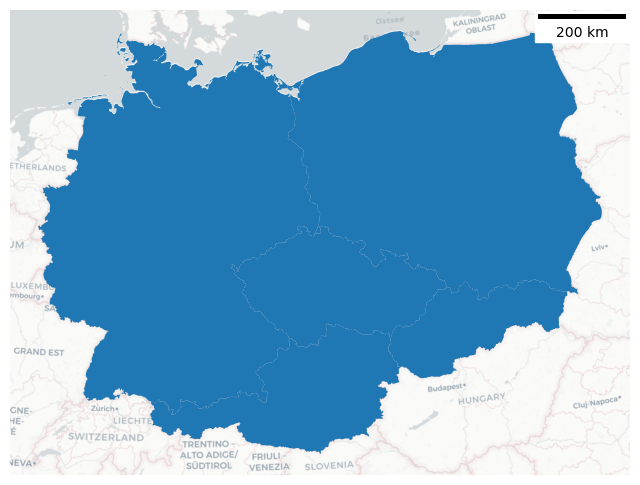

In [9]:
import contextily as cx
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

fig, ax = plt.subplots(figsize=(8,8))
country_polygons.plot(ax=ax)
ax.set_axis_off()
cx.add_basemap(ax, crs=country_polygons.crs, source=cx.providers.CartoDB.Positron.build_url(scale_factor="@2x",))
ax.add_artist(ScaleBar(1, location="upper right"))

In [10]:
intersection_df = gpd.GeoDataFrame(
    {
    'region_id': region_hulls.index[region_idxs].values,
    'country': country_polygons.iloc[country_idxs, 2].values,
    'intersection_area': intersections.values,
    'geometry': region_hulls.iloc[region_idxs, 0].values
    },
    crs=region_hulls.crs
                                   
                                  
)

intersection_df = intersection_df.sort_values(['country', 'intersection_area'], ascending=False)
# intersection_df = intersection_df[~intersection_df.region_id.duplicated()].sort_values('region_id')
# assert (intersection_df.region_id == region_hulls.index).all()

In [11]:
def combine_regions_data(selected_regions, area_geom, char_type='primary'):
    """Combine the morphometric data, target labels and hexagons from all of the 'selected_regions' into a single dataframe for model training."""
    
    all_data = []
    all_labels = []
    all_hexagons = []
    
    for i, trid in enumerate(selected_regions):

        if i % 100 == 0:
            print(i, trid)

        # select only those buildings within the target area geometry
        buildings = gpd.read_parquet(f'{coredir}processed_data/buildings/buildings_{trid}.parquet', columns=['geometry'])
        buildings = buildings.index[buildings.centroid.sindex.query(area_geom, predicate='contains')].values
        
        
        if char_type == 'weighted_lag':
            data = pd.read_parquet(f'/data/uscuni-eurofab/processed_data/chars/lag_chars_{trid}_{kernel}_{spatial_lag}_{bandwith_type}.parquet')
            data = data.astype(np.float32)
            data.index = data.index.astype(np.int32)
        elif char_type == 'unweighted_lag':
            data = pd.read_parquet(f'/data/uscuni-eurofab/processed_data/chars/lag_chars_{trid}_unweighted_{spatial_lag}.parquet')
            data = data.astype(np.float32)
            data.index = data.index.astype(np.int32)
        elif char_type == 'primary':
            data = pd.read_parquet(f'{data_dir}primary_chars_{trid}.parquet')
        elif char_type == 'only_unweighted_lag':
            data = pd.read_parquet(f'/data/uscuni-eurofab/processed_data/chars/lag_chars_{trid}_unweighted_{spatial_lag}.parquet')
            data = data.astype(np.float32)
            data.index = data.index.astype(np.int32)
            iqr = pd.DataFrame(data.loc[:, data.columns.str.contains('_85')].values - data.loc[:, data.columns.str.contains('_15')].values, 
                         index=data.index, 
                         columns=data.columns[~data.columns.str.contains('_')] + '_iqr')
            median = data.loc[:, data.columns.str.contains('_median')]
            data = pd.merge(iqr, median, left_index=True, right_index=True)
        
        elif char_type == 'primary_overture':
            # same as primary data, but add a data source column from the building parquet
            data = pd.read_parquet(f'{data_dir}primary_chars_{trid}.parquet')
            data_source = pd.read_parquet(f"{data_dir}buildings_chars_{trid}.parquet", columns=['source', 'class'])
            data['source'] = data_source['source']
        elif char_type == 'unweighted_lag_overture':
            # same as unweighted lag, but add a data source column from the building parquet and only save the median
            data = pd.read_parquet(f'/data/uscuni-eurofab-overture/processed_data/chars/lag_chars_{trid}_unweighted_{spatial_lag}.parquet')
            data = data.astype(np.float32)
            data.index = data.index.astype(np.int32)
            data_source = pd.read_parquet(f"{data_dir}buildings_chars_{trid}.parquet", columns=['source', 'class'])
            data['source'] = data_source['source']
            data = data.loc[:, ~data.columns.str.contains('_') | data.columns.str.contains('_median')]
        elif char_type == 'only_unweighted_lag_overture':
            # keep only median and iqr from the lag, no primary chars
            data = pd.read_parquet(f'/data/uscuni-eurofab-overture/processed_data/chars/lag_chars_{trid}_unweighted_{spatial_lag}.parquet')
            data = data.astype(np.float32)
            data.index = data.index.astype(np.int32)
            iqr = pd.DataFrame(data.loc[:, data.columns.str.contains('_85')].values - data.loc[:, data.columns.str.contains('_15')].values, 
                         index=data.index, 
                         columns=data.columns[~data.columns.str.contains('_')] + '_iqr')
            median = data.loc[:, data.columns.str.contains('_median')]
            data = pd.merge(iqr, median, left_index=True, right_index=True)

           

        else:
            raise Exception('Datatype does not exist')

        data = data.loc[buildings]
        
        targets = pd.read_parquet(f'{target_dir}{trid}_target.pq').set_index('index')
        hexagons = pd.read_parquet(f'{hex_dir}{trid}_hexagon.pq').set_index('index')

        # drop empty tess to save some memory
        targets = targets[targets.index > -1]
    
        common_index = data.index.join(targets.index, how='inner').join(hexagons.index, how='inner')
        data = data.loc[common_index]
        targets = targets.loc[common_index]
        hexagons = hexagons.loc[common_index]
    
        # record region_id in the index
        common_index = str(trid) + '_' + common_index.astype(str)
        
        data = data.set_index(common_index)
        targets = targets.set_index(common_index)
        hexagons = hexagons.set_index(common_index)
    
        all_data.append(data)
        all_labels.append(targets)
        all_hexagons.append(hexagons)
    
    
    all_data = pd.concat(all_data)
    all_labels = pd.concat(all_labels)
    all_hexagons = pd.concat(all_hexagons)
    
    return all_data, all_labels, all_hexagons

Generate the final country level train/test datasets.

In [12]:
%%time

training_countries = TRAINING1
testing_countries = TESTING1
i = 1

training_regions = intersection_df[intersection_df['country'].isin(training_countries)].region_id.values
training_country_area = country_polygons[country_polygons.NAME_ENGL.isin(training_countries)].geometry.union_all()
testing_regions = intersection_df[intersection_df['country'].isin(testing_countries)].region_id.values
testing_country_area = country_polygons[country_polygons.NAME_ENGL.isin(testing_countries)].geometry.union_all()

all_data, all_labels, all_hexagons = combine_regions_data(training_regions, training_country_area, char_type=char_type)

all_data.to_parquet(f'{coredir}processed_data/train_test_data/training_data{i}.pq')
all_labels.to_parquet(f'{coredir}processed_data/train_test_data/training_labels{i}.pq')
all_hexagons.to_parquet(f'{coredir}processed_data/train_test_data/training_hexagons{i}.pq')


all_data, all_labels, all_hexagons = combine_regions_data(testing_regions, testing_country_area, char_type=char_type)

all_data.to_parquet(f'{coredir}processed_data/train_test_data/testing_data{i}.pq')
all_labels.to_parquet(f'{coredir}processed_data/train_test_data/testing_labels{i}.pq')

0 104396
100 116035
200 30571
300 57118
400 57959
500 47308
0 104396
CPU times: user 16min 47s, sys: 6min 59s, total: 23min 47s
Wall time: 9min 4s


In [13]:
%%time

training_countries = TRAINING2
testing_countries = TESTING2
i = 2


training_regions = intersection_df[intersection_df['country'].isin(training_countries)].region_id.values
training_country_area = country_polygons[country_polygons.NAME_ENGL.isin(training_countries)].geometry.union_all()
testing_regions = intersection_df[intersection_df['country'].isin(testing_countries)].region_id.values
testing_country_area = country_polygons[country_polygons.NAME_ENGL.isin(testing_countries)].geometry.union_all()

all_data, all_labels, all_hexagons = combine_regions_data(training_regions, training_country_area, char_type=char_type)

all_data.to_parquet(f'{coredir}processed_data/train_test_data/training_data{i}.pq')
all_labels.to_parquet(f'{coredir}processed_data/train_test_data/training_labels{i}.pq')
all_hexagons.to_parquet(f'{coredir}processed_data/train_test_data/training_hexagons{i}.pq')


all_data, all_labels, all_hexagons = combine_regions_data(testing_regions, testing_country_area, char_type=char_type)

all_data.to_parquet(f'{coredir}processed_data/train_test_data/testing_data{i}.pq')
all_labels.to_parquet(f'{coredir}processed_data/train_test_data/testing_labels{i}.pq')

0 104396
100 15540
200 39903
300 57959
0 104396
100 116035
CPU times: user 16min 5s, sys: 6min 22s, total: 22min 27s
Wall time: 8min 20s


In [14]:
%%time

training_countries = TRAINING3
testing_countries = TESTING3
i = 3

training_regions = intersection_df[intersection_df['country'].isin(training_countries)].region_id.values
training_country_area = country_polygons[country_polygons.NAME_ENGL.isin(training_countries)].geometry.union_all()
testing_regions = intersection_df[intersection_df['country'].isin(testing_countries)].region_id.values
testing_country_area = country_polygons[country_polygons.NAME_ENGL.isin(testing_countries)].geometry.union_all()

all_data, all_labels, all_hexagons = combine_regions_data(training_regions, training_country_area, char_type=char_type)

all_data.to_parquet(f'{coredir}processed_data/train_test_data/training_data{i}.pq')
all_labels.to_parquet(f'{coredir}processed_data/train_test_data/training_labels{i}.pq')
all_hexagons.to_parquet(f'{coredir}processed_data/train_test_data/training_hexagons{i}.pq')


all_data, all_labels, all_hexagons = combine_regions_data(testing_regions, testing_country_area, char_type=char_type)

all_data.to_parquet(f'{coredir}processed_data/train_test_data/testing_data{i}.pq')
all_labels.to_parquet(f'{coredir}processed_data/train_test_data/testing_labels{i}.pq')

0 104396
100 97027
200 75752
0 2415
100 41257
200 47311
CPU times: user 16min 19s, sys: 6min 19s, total: 22min 39s
Wall time: 8min 5s


In [15]:
%%time

training_countries = TRAINING4
testing_countries = TESTING4
i = 4

training_regions = intersection_df[intersection_df['country'].isin(training_countries)].region_id.values
training_country_area = country_polygons[country_polygons.NAME_ENGL.isin(training_countries)].geometry.union_all()
testing_regions = intersection_df[intersection_df['country'].isin(testing_countries)].region_id.values
testing_country_area = country_polygons[country_polygons.NAME_ENGL.isin(testing_countries)].geometry.union_all()

all_data, all_labels, all_hexagons = combine_regions_data(training_regions, training_country_area, char_type=char_type)

all_data.to_parquet(f'{coredir}processed_data/train_test_data/training_data{i}.pq')
all_labels.to_parquet(f'{coredir}processed_data/train_test_data/training_labels{i}.pq')
all_hexagons.to_parquet(f'{coredir}processed_data/train_test_data/training_hexagons{i}.pq')


all_data, all_labels, all_hexagons = combine_regions_data(testing_regions, testing_country_area, char_type=char_type)

all_data.to_parquet(f'{coredir}processed_data/train_test_data/testing_data{i}.pq')
all_labels.to_parquet(f'{coredir}processed_data/train_test_data/testing_labels{i}.pq')

0 104396
100 97027
200 22022
300 20008
400 68368
500 97027
0 61799
CPU times: user 16min 39s, sys: 7min 7s, total: 23min 47s
Wall time: 9min 30s


In [16]:
%%time

training_countries = TRAINING5
testing_countries = TESTING5
i = 5

training_regions = intersection_df[intersection_df['country'].isin(training_countries)].region_id.values
training_country_area = country_polygons[country_polygons.NAME_ENGL.isin(training_countries)].geometry.union_all()
testing_regions = intersection_df[intersection_df['country'].isin(testing_countries)].region_id.values
testing_country_area = country_polygons[country_polygons.NAME_ENGL.isin(testing_countries)].geometry.union_all()

all_data, all_labels, all_hexagons = combine_regions_data(training_regions, training_country_area, char_type=char_type)

all_data.to_parquet(f'{coredir}processed_data/train_test_data/training_data{i}.pq')
all_labels.to_parquet(f'{coredir}processed_data/train_test_data/training_labels{i}.pq')
all_hexagons.to_parquet(f'{coredir}processed_data/train_test_data/training_hexagons{i}.pq')


all_data, all_labels, all_hexagons = combine_regions_data(testing_regions, testing_country_area, char_type=char_type)

all_data.to_parquet(f'{coredir}processed_data/train_test_data/testing_data{i}.pq')
all_labels.to_parquet(f'{coredir}processed_data/train_test_data/testing_labels{i}.pq')

0 104396
100 97027
200 22022
300 20008
400 68368
0 90747
CPU times: user 16min 41s, sys: 6min 24s, total: 23min 5s
Wall time: 9min 18s


In [17]:
%%time

# 6 is the insample model without spatial grouping (hexagons)

target_area = country_polygons.geometry.union_all()
all_data, all_labels, all_hexagons = combine_regions_data(region_hulls.index.values, target_area, char_type=char_type)


from sklearn.model_selection import StratifiedKFold
gkf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
splits = gkf.split(
    all_data,
    y=all_labels.final_without_noise,
)
split_label = np.empty(len(all_data), dtype=float)
for i, (train, test) in enumerate(splits):
    split_label[test] = i



i = 6

# assign four of the groups as training data
train = split_label != 0
all_data.loc[train].to_parquet(f'{coredir}processed_data/train_test_data/training_data{i}.pq')
all_labels.loc[train].to_parquet(f'{coredir}processed_data/train_test_data/training_labels{i}.pq')
all_hexagons.loc[train].to_parquet(f'{coredir}processed_data/train_test_data/training_hexagons{i}.pq')

# assign one of the groups as test data
test = split_label == 0
all_data.loc[test].to_parquet(f'{coredir}processed_data/train_test_data/testing_data{i}.pq')
all_labels.loc[test].to_parquet(f'{coredir}processed_data/train_test_data/testing_labels{i}.pq')

0 19
100 17951
200 45681
300 81666
400 109949
CPU times: user 9min 27s, sys: 4min 55s, total: 14min 22s
Wall time: 5min 53s


In [18]:
%%time

# 7 is the insample model with spatial grouping (hexagons)

target_area = country_polygons.geometry.union_all()

all_data, all_labels, all_hexagons = combine_regions_data(region_hulls.index.values, target_area, char_type=char_type)

from sklearn.model_selection import StratifiedGroupKFold
gkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=123)
splits = gkf.split(
    all_data,
    y=all_labels.final_without_noise,
    groups=all_hexagons.hexagons,
)
split_label = np.empty(len(all_data), dtype=float)
for i, (train, test) in enumerate(splits):
    split_label[test] = i



i = 7

# assign four of the groups as training data
train = split_label != 0
all_data.loc[train].to_parquet(f'{coredir}processed_data/train_test_data/training_data{i}.pq')
all_labels.loc[train].to_parquet(f'{coredir}processed_data/train_test_data/training_labels{i}.pq')
all_hexagons.loc[train].to_parquet(f'{coredir}processed_data/train_test_data/training_hexagons{i}.pq')


# assign one of the groups as test data
test = split_label == 0
all_data.loc[test].to_parquet(f'{coredir}processed_data/train_test_data/testing_data{i}.pq')
all_labels.loc[test].to_parquet(f'{coredir}processed_data/train_test_data/testing_labels{i}.pq')

0 19
100 17951
200 45681
300 81666
400 109949
CPU times: user 10min 8s, sys: 5min 13s, total: 15min 22s
Wall time: 6min 42s


### Plot testing regions

In [17]:
training_countries = TRAINING4
testing_countries = TESTING4
i = 4

training_regions = intersection_df[intersection_df['country'].isin(training_countries)].region_id.values
testing_regions = intersection_df[intersection_df['country'].isin(testing_countries)].region_id.values
region_hulls.loc[testing_regions].explore()